In [7]:
import sys
sys.path.append("..")

from src.data import download_data
import pandas as pd
import matplotlib.pyplot as plt

tickers = ["SPY", "AAPL", "MSFT", "AMZN"]
prices = download_data(tickers, start="2020-01-01", end="2024-01-01")
prices.head()

[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,AMZN,MSFT,SPY
Date,,,,
2020-01-02,72.333878,94.900497,151.829544,296.888153
2020-01-03,71.630653,93.748497,149.939026,294.640076
2020-01-06,72.201431,95.143997,150.326584,295.764160
2020-01-07,71.861832,95.343002,148.955948,294.932556
2020-01-08,73.017838,94.598503,151.328522,296.504364


In [8]:
print(f"Periodo: {prices.index[0].date()} a {prices.index[-1].date()}")
print(f"Días de trading: {len(prices)}")
print(f"Datos faltantes por columna:\n{prices.isnull().sum()}")

Periodo: 2020-01-02 a 2023-12-29
Días de trading: 1006
Datos faltantes por columna:
Ticker
AAPL    0
AMZN    0
MSFT    0
SPY     0
dtype: int64


In [9]:
prices.describe()

Ticker,AAPL,AMZN,MSFT,SPY
count,1006.000000,1006.000000,1006.000000,1006.000000
mean,137.831006,137.216247,253.632410,373.731792
std,33.327124,27.468805,54.692254,53.312033
min,54.163700,81.820000,128.358368,204.944870
25%,120.286201,114.309002,212.372936,343.524628
50%,142.684914,140.585007,250.385048,386.640991
75%,163.044834,161.190620,293.126953,415.252785
max,195.892593,186.570496,375.406036,463.923004


In [9]:
# Retorno = cambio porcentual día a día
returns = prices.pct_change().dropna()
returns.head()

Ticker,AAPL,AMZN,MSFT,SPY
Date,,,,
2020-01-03,-0.009722,-0.012139,-0.012452,-0.007572
2020-01-06,0.007968,0.014886,0.002585,0.003815
2020-01-07,-0.004703,0.002092,-0.009118,-0.002812
2020-01-08,0.016086,-0.007809,0.015929,0.005329
2020-01-09,0.021241,0.004799,0.012493,0.006781


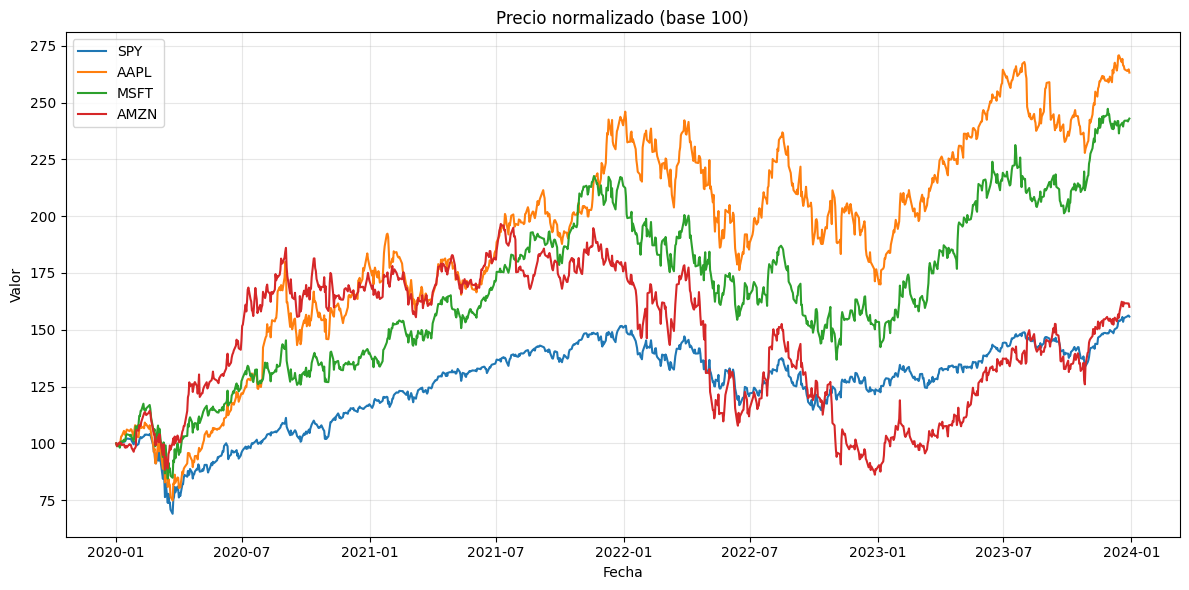

In [10]:
plt.figure(figsize=(12, 6))
for ticker in tickers:
    # Normalizamos a base 100 para comparar
    normalized = (prices[ticker] / prices[ticker].iloc[0]) * 100
    plt.plot(normalized, label=ticker)

plt.title("Precio normalizado (base 100)")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../output/precios_normalizados.png", dpi=150)
plt.show()

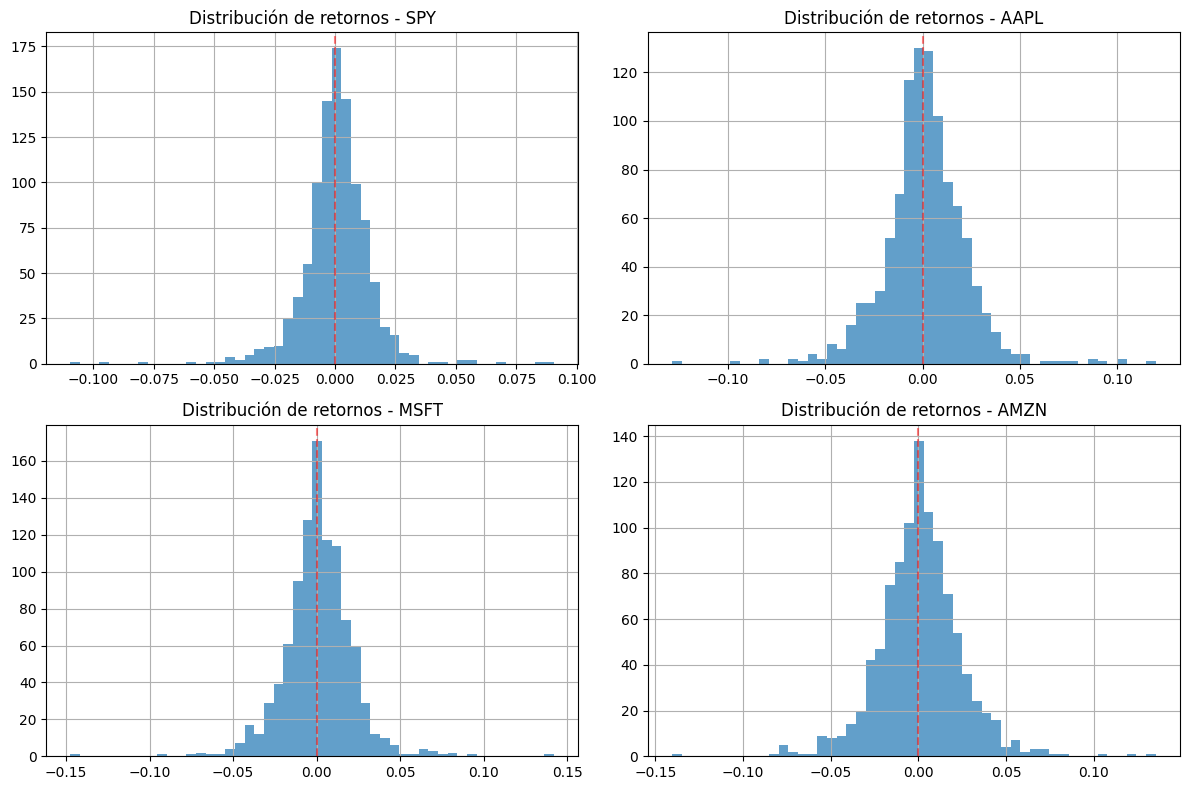

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, ticker in zip(axes.flatten(), tickers):
    returns[ticker].hist(bins=50, ax=ax, alpha=0.7)
    ax.set_title(f"Distribución de retornos - {ticker}")
    ax.axvline(0, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../output/distribucion_retornos.png", dpi=150)
plt.show()

In [12]:
correlation = returns.corr()
print("=== Matriz de correlación ===")
print(correlation.round(3))

=== Matriz de correlación ===
Ticker   AAPL   AMZN   MSFT    SPY
Ticker                            
AAPL    1.000  0.624  0.777  0.816
AMZN    0.624  1.000  0.679  0.642
MSFT    0.777  0.679  1.000  0.826
SPY     0.816  0.642  0.826  1.000


In [13]:
vol = returns.std() * (252 ** 0.5)  # 252 días de trading al año
print("=== Volatilidad anualizada ===")
for ticker in tickers:
    print(f"{ticker}: {vol[ticker]:.2%}")

=== Volatilidad anualizada ===
SPY: 22.63%
AAPL: 33.57%
MSFT: 32.62%
AMZN: 37.69%
